# Notebook 09 — Visualising the Morphing Shape Modes

> **Supplementary §10**

Notebook 04 introduced the 12 morphing shape modes, showed their loadings, and previewed a single mode animation. This notebook provides the **full mode-by-mode visualisation**: systematic animations for all nine interpretable modes, reconstruction accuracy as a function of mode count, and evidence that realistic flight shapes require coordinated combinations of multiple modes.

## Contents
1. [Setup and data loading](#setup)
2. [Animating individual morphing modes](#animating-modes)
3. [Mode categories and interpretation](#mode-categories)
4. [Shape reconstruction accuracy](#reconstruction-accuracy)
5. [Coordinated mode interaction](#coordinated-modes)
6. [Summary](#summary)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=3)

from morphing_birds import Animal3D, plot_plotly, animate_plotly, animate, animate_mode

from kinematic_morphospace import (
    filter_by, run_PCA, reconstruct, to_bilateral, apply_sign_conventions,
    get_score_df, get_score_range, get_binned_scores,
)
from kinematic_morphospace.plotting import (
    plot_explained, plot_components_grid,
    plot_hist_similar_shapes,
    save_figure,
)

## Load Data

We load the unilateral marker data, the PCA results from Notebook 04, and the mean hawk shape for 3D visualisation.

In [2]:
unilateral_data = np.load("../../data/unilateral/data.npy")
unilateral_frame_info_df = pd.read_csv("../../data/unilateral/frame_info.csv")

principal_components = np.load("../../data/unilateral/principal_components.npy")
scores = np.load("../../data/unilateral/scores.npy")
mu = np.load("../../data/unilateral/mean_shape.npy").reshape(1, -1, 3)

# Reload PCA object for variance ratios
filt = filter_by(unilateral_frame_info_df, obstacle=0)
_, _, pca = run_PCA(unilateral_data[filt], unilateral_data)

hawk3d = Animal3D('hawk', '../../data/mean_hawk_shape.csv')

print(f"Scores shape: {scores.shape}")
print(f"Components shape: {principal_components.shape}")
print(f"Mean shape: {mu.shape}")

Scores shape: (289528, 12)
Components shape: (12, 12)
Mean shape: (1, 4, 3)


In [3]:
colour_list = ['#B5E675', '#6ED8A9', '#51B3D4',
               '#4579AA', '#F19EBA', '#BC96C9',
               '#917AC2', '#BE607F', '#624E8B',
               '#888888', '#888888', '#888888']

mode_names = [
    "Wing lifting / lowering",
    "Wing spreading / contracting",
    "Wing sweeping forwards / backwards",
    "Tail spreading",
    "Counter pitching",
    "Hand-wing spreading / contracting",
    "M folding/ W folding",
    "Hand-wing sweeping forwards / backwards",
    "Hand-wing shape",
    "Noise", "Noise", "Noise",
]

## Animating Individual Morphing Modes

Each morphing mode is visualised by sweeping its score between ±2 standard deviations from the mean while holding all other scores at zero. This produces a synthetic animation showing the physical shape change each mode encodes.

**A note on what PCA modes interpretation.** PCA modes are statistical axes of variation, not actuation axes or degrees of freedom of the hawk's musculoskeletal system. The hawk does not have a "mode 1 muscle" that lifts the wing and a "mode 2 muscle" that spreads it. Rather, PCA finds the directions in shape space along which the data vary most, subject to the constraint that each successive mode is orthogonal to all previous ones. The resulting modes are interpretable — mode 1 clearly corresponds to flapping, mode 2 to spreading — but these are *emergent patterns* in the data, not biomechanical control inputs.

This distinction matters for two reasons. First, the orthogonality constraint is mathematical, not biological: the hawk's actual control axes need not be orthogonal, and correlated joint motions will be split across multiple PCA modes. Second, the ordering of modes (by decreasing variance) and their orientation depend on the dataset. A different sample of flights, or data from a single hawk, may produce rotated axes within the same subspace (as shown in Notebook 08). The modes describe how shape *varies* across the observed flights, not how the hawk *controls* its shape. However, within a given mode these show the highly correlated shape changes that the hawks use and are useful patterns for interpretation and comparison across individuals and manoeuvres. 

The score range is generated from the full dataset, ensuring the animation spans the realistic range of variation observed across all flights.

>**Note:** These single-mode animations show bilaterally symmetrical morphing changes, because each mode was extracted from the rotation-corrected unilateral data. The left side is reconstructed by mirroring the right.


### Mode 1 — Wing Lifting (~67% variance)

The dominant morphing mode captures the primary flapping axis: the wing rises and falls as a whole unit. This single mode accounts for two-thirds of all shape variation.

In [4]:
animate_mode(1, hawk3d, principal_components, scores, mu, colour_list,
             sign_fn=apply_sign_conventions)

  Sign conventions applied: PC07 negated (positive = m-folded)


### Mode 2 — Wing Spreading (~25% variance)

The second mode captures wing extension and retraction — the transition between spread and tucked postures. Together with Mode 1, these two modes account for ~92% of variance.

In [5]:
animate_mode(2, hawk3d, principal_components, scores, mu, colour_list,
             sign_fn=apply_sign_conventions)

  Sign conventions applied: PC07 negated (positive = m-folded)


### Mode 3 — Wing Sweeping (~3% variance)

The third mode captures forward and backward sweeping of the wing. Though it explains only ~3% of variance, it represents a distinct and interpretable planform change.

In [6]:
animate_mode(3, hawk3d, principal_components, scores, mu, colour_list,
             sign_fn=apply_sign_conventions)

  Sign conventions applied: PC07 negated (positive = m-folded)


### Mode 4 — Tail Spreading (~2% variance)

The fourth mode isolates tail spreading and contraction. These first four modes together capture ~96.3% of all morphing variance and describe the **major planform shape changes**.

In [7]:
animate_mode(4, hawk3d, principal_components, scores, mu, colour_list,
             sign_fn=apply_sign_conventions)

  Sign conventions applied: PC07 negated (positive = m-folded)


## Mode Categories and Interpretation

Notebook 04 previewed the loadings heatmap and mode descriptions. Here we present the full functional categorisation (§10.2) alongside the loadings, showing which markers and coordinates contribute most to each mode:

| Category | Modes | Combined variance | Description |
|----------|-------|-------------------|-------------|
| **Major planform** | 1-4 | ~96.3% | Wing lifting, spreading, sweeping, tail spreading |
| **Local incidence** | 5, 8 | ~1.35% | Angle-of-attack adjustments at wrist and elbow |
| **Hand-wing shape** | 6, 7, 9 | ~1.62% | Twist, camber, and shape of the outer wing |
| **Noise** | 10-12 | ~0.69% | Measurement noise and minor residuals |

(<Figure size 500x500 with 2 Axes>, <Axes: xlabel='Component Number'>)

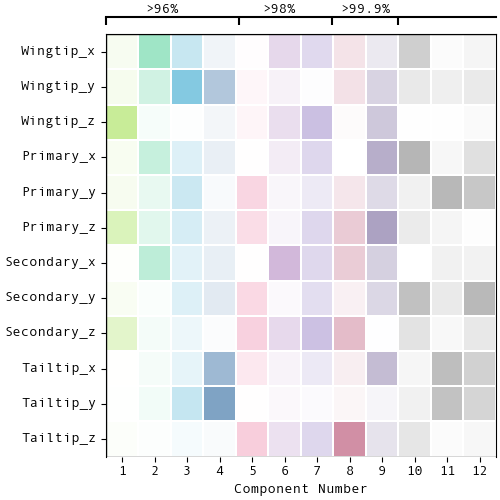

In [8]:
marker_labels = [f"{m}_{a}" for m in ["Wingtip", "Primary", "Secondary", "Tailtip"] for a in ["x", "y", "z"]]
plot_components_grid(
    principal_components,
    marker_names=marker_labels
)
# plt.savefig("../../figures/SuppFig_Mode_Loadings.pdf")

### Higher Modes (5-9)

Modes 5-9 describe finer adjustments. They can also be animated to inspect their physical interpretation.

In [9]:
# Animate modes 5-9 (select one at a time)
animate_mode(8, hawk3d, principal_components, scores, mu, colour_list,
             sign_fn=apply_sign_conventions)

  Sign conventions applied: PC07 negated (positive = m-folded)


## Exporting Mode Animations as GIFs

The interactive Plotly animations above are ideal for exploration, but static GIF files are useful for sharing, embedding in presentations, and archival. Each mode is rendered from a fixed viewing angle chosen for interpretability.

For the full interactive 3D version, see the [online morphing wings visualisation](https://lydiafrance.github.io/LydiaFrance/projects/morphing-wings/page3.html).

In [10]:
import os

os.makedirs('../../figures/gifs', exist_ok=True)

# Viewing angles per mode, chosen for interpretability in the original analysis
el_list = [20, 90, 90, 20, 10, 30,  0, 10, 20, 20, 20, 20]
az_list = [60, 90, 90, 60, 20, 60, 90, 20, 60, 60, 60, 60]

score_frames = get_score_range(scores, num_frames=25)

plt.ioff()  # Suppress interactive display during batch export
for pc in range(1, 13):
    hawk3d.reset_transformation()

    component_index = [pc - 1]
    reconstructed = reconstruct(score_frames, principal_components, mu, component_index)
    recon_bilateral = to_bilateral(reconstructed)

    ani = animate(hawk3d, recon_bilateral,
                  colour=colour_list[pc - 1],
                  el=el_list[pc - 1],
                  az=az_list[pc - 1],
                  alpha=0.7,
                  axes_visible=False)

    path = f"../../figures/gifs/MorphingMode_PC{pc:02d}.gif"
    ani.save(path, writer='Pillow', fps=10, dpi=150)
    plt.close(ani._fig)
    print(f"Saved {path}")
plt.ion()

MovieWriter Pillow unavailable; using Pillow instead.
MovieWriter Pillow unavailable; using Pillow instead.


Saved ../../figures/gifs/MorphingMode_PC01.gif


MovieWriter Pillow unavailable; using Pillow instead.


Saved ../../figures/gifs/MorphingMode_PC02.gif


MovieWriter Pillow unavailable; using Pillow instead.


...

Saved ../../figures/gifs/MorphingMode_PC09.gif


MovieWriter Pillow unavailable; using Pillow instead.


Saved ../../figures/gifs/MorphingMode_PC10.gif


MovieWriter Pillow unavailable; using Pillow instead.


Saved ../../figures/gifs/MorphingMode_PC11.gif
Saved ../../figures/gifs/MorphingMode_PC12.gif


## Shape Reconstruction Accuracy

How many modes are needed to faithfully reconstruct real flight shapes? We compute the root mean square (RMS) reconstruction error as a function of the number of modes used.

From §10.3:
- 1 mode: RMS error ~4.5% of wingspan (~4.5-5 cm)
- 4 modes: error falls below 1.5 cm
- 6 modes: error falls to ~1 cm across all individuals
- Beyond 8 modes: improvements are negligible

In [11]:
# Compute reconstruction error vs number of components
from kinematic_morphospace.pca_core import get_PCA_input

filt = filter_by(unilateral_frame_info_df, obstacle=0)
test_data = unilateral_data[filt]
test_input = get_PCA_input(test_data)

# Use pooled PCA
test_scores = pca.transform(test_input)

errors = []
for n_comp in range(1, 13):
    recon = test_scores[:, :n_comp] @ pca.components_[:n_comp, :] + pca.mean_
    rmse = np.sqrt(np.mean((test_input - recon) ** 2))
    cev = np.sum(pca.explained_variance_ratio_[:n_comp])
    errors.append({"Modes": n_comp, "RMSE": rmse, "CEV": cev})

error_df = pd.DataFrame(errors)
print(error_df.to_string(index=False))

 Modes         RMSE      CEV
     1 4.484836e-02 0.665811
     2 2.262041e-02 0.914984
     3 1.867703e-02 0.942042
     4 1.487015e-02 0.963261
     5 1.303079e-02 0.971788
     6 1.138215e-02 0.978475
     7 9.711606e-03 0.984330
     8 8.008567e-03 0.989344
     9 6.454382e-03 0.993078
    10 4.840455e-03 0.996107
    11 3.074438e-03 0.998430
    12 1.113502e-16 1.000000


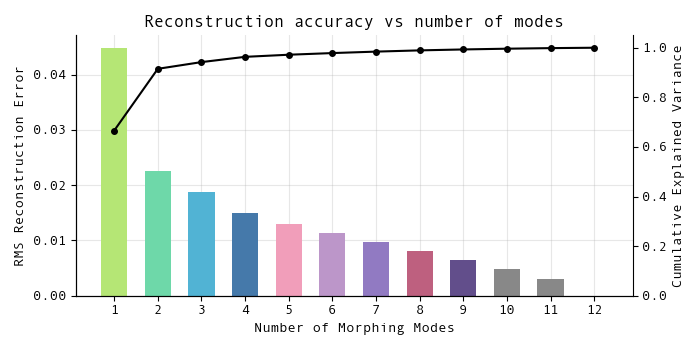

In [12]:
# Plot reconstruction error
fig, ax1 = plt.subplots(figsize=(7, 3.5))

ax1.bar(error_df['Modes'], error_df['RMSE'], color=colour_list[:12],
        width=0.6, edgecolor='none', zorder=2)
ax1.set_xlabel("Number of Morphing Modes")
ax1.set_ylabel("RMS Reconstruction Error")
ax1.set_xticks(range(1, 13))
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Overlay CEV line
ax2 = ax1.twinx()
ax2.plot(error_df['Modes'], error_df['CEV'], 'ko-', markersize=4, zorder=3)
ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_ylim(0, 1.05)
ax2.spines['top'].set_visible(False)

plt.title("Reconstruction accuracy vs number of modes")
plt.tight_layout()
plt.show()

## Coordinated Mode Interaction

Real morphing arises from the coordinated interaction of multiple modes, not individual modes in isolation (§10.2). To demonstrate this, we compare:

1. **Similar shapes:** For each point in PC score space, how many real observed frames fall within a threshold RMS distance of the reconstructed shape?
2. **Score frequency:** How often does each score combination actually occur?

If score frequency and shape similarity matched perfectly, individual modes would suffice to describe flight. The 2D histogram of Modes 1 vs 2 (which capture ~92% of variance) shows a closer match between frequency and similarity than the 1D histograms — confirming that flight control relies on coordinated adjustments along multiple axes.

Computing high resolution for 538 points out of 2500 (21.5%)


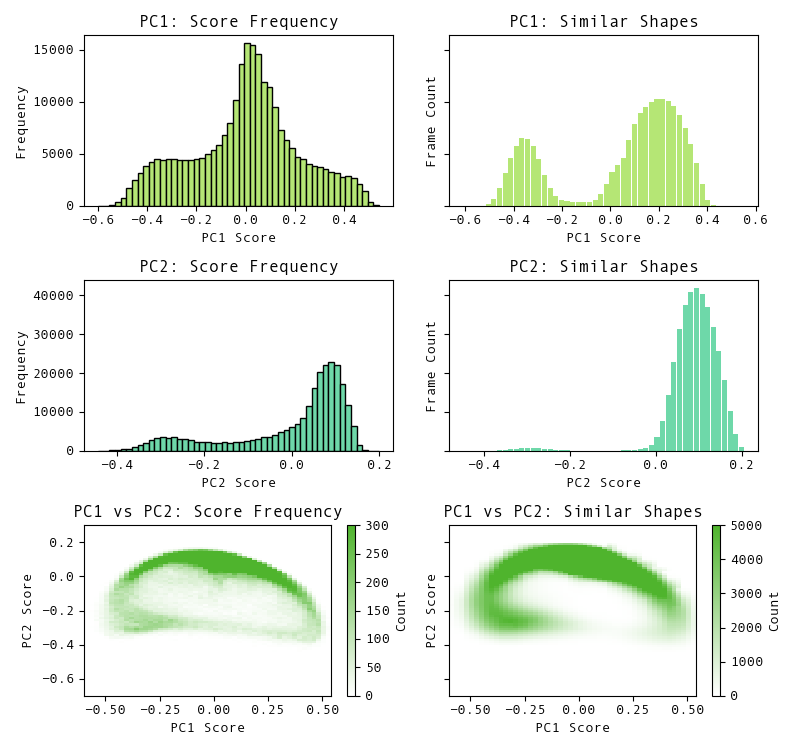

Saved: ../../figures/supplementary/S10_score_distributions.pdf


In [14]:
# Score similarity analysis (1D per mode + 2D for Mode 1 vs 2)
filt = filter_by(unilateral_frame_info_df, obstacle=0)
marker_data = unilateral_data[filt]

fig, axes = plot_hist_similar_shapes(
    principal_components, scores[filt], marker_data,
    pc_indices=[0, 1], threshold=0.025
)
save_figure(fig, '../../figures/supplementary/S10_score_distributions.pdf')

**Interpretation.** The 1D histograms show a mismatch: while every score value has *some* matching real frames, the distribution of similar shapes does not track the score frequency closely. A given mode 1 score predicts the general flapping position but does not pin down the actual wing shape — many different real configurations share the same mode 1 value because the other modes (spreading, sweeping, tail position) vary independently.

The 2D histogram (modes 1 vs 2, bottom row) shows a much closer correspondence between score frequency and shape similarity. This is expected: together these two modes capture >90% of variance, so specifying both narrows the shape considerably. But the match is still imperfect — confirming that even the two dominant modes cannot fully reconstruct real flight shapes without contributions from the remaining modes.

This reinforces the point made above: PCA modes are not independent control channels. Real wing–tail configurations arise from the coordinated combination of all modes. The modes provide a useful *coordinate system* for describing shape variation, but individual modes should not be interpreted as isolated biomechanical actuations.


## Summary

The morphing shape modes have clear physical interpretations and provide an efficient description of hawk wing-tail shape:

- **Four modes** capture ~96.3% of variance, describing the major planform changes (lifting, spreading, sweeping, tail spreading).
- **Nine modes** capture >99% of variance; the remaining three are noise.
- **Reconstruction accuracy** improves rapidly: 4 modes reduce RMS error below 1.5 cm; 6 modes bring it to ~1 cm.
- **Realistic flight shapes** arise from **coordinated combinations** of multiple modes. Individual modes in isolation produce shapes that rarely occur in nature.

These results confirm that the morphing shape mode coordinate system is both compact and faithful — a low-dimensional representation that preserves the essential geometry of hawk flight morphing.

---

## References

- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer-Verlag.
- KleinHeerenbrink, M., France, L. A., Brighton, C. H. & Taylor, G. K. (2022). Optimization of avian perching manoeuvres. *Nature*, 607, 91–96.